<a href="https://colab.research.google.com/github/KevintheChris/An-lise-de-Dados---Delivery-Center-De-Power-BI-para-Python-/blob/main/Deliver_center.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

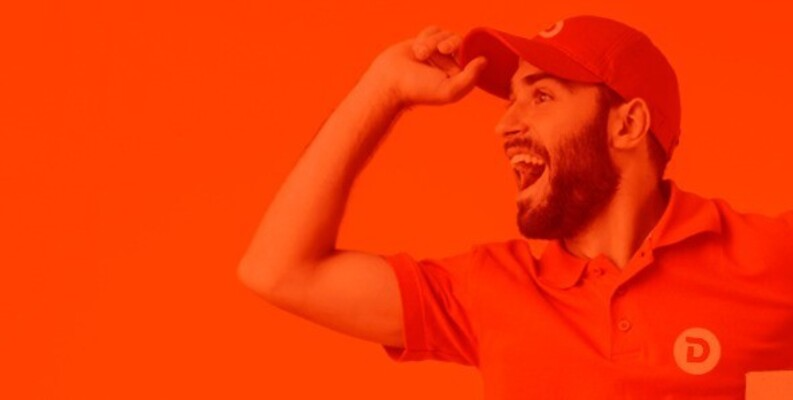

# **Delivery Center: Food & Goods orders in Brazil**
**Food and Goods Deliveries in Brazil**

**O que é o Delivery Center**

Com seus diversos hubs operacionais espalhados pelo Brasil, o Delivery Center é uma plataforma integra lojistas e marketplaces, criando um ecossistema saudável para vendas de good (produtos) e food (comidas) no varejo brasileiro.

Atualmente temos um cadastro (catálogo + cardápio) com mais de 900 mil itens, milhares de pedidos e entregas são operacionalizados diariamente com uma rede de milhares lojistas e entregadores parceiros espalhados por todas as regiões do país.

Tudo isso gera dados e mais dados a todo momento!

Diante disso, nosso negócio está cada vez data driven, ou seja, utilizando dados para tomar decisões e numa visão de futuro sabemos que utilizar os dados de forma inteligente pode ser o nosso grande diferencial no mercado.

Este é o nosso contexto e com ele lhe propomos um desafio desafio em que você possa aplicar seus conhecimentos técnicos objetivando resolver problemas cotidianos de uma equipe de dados.

## **Auxiliando os Times de Marketing e Pricing da Empresa de Delivery**
---

Agora apresentado o dataset, irei fazer esse projeto em quatro analises para entregar esses resultados, simulando questões rais para diversos setores dentro de uma empresa para entregar valor real para ela. Desafios para praticar da  Universidade dos dados.

Primeiro pedido é:

"Numa ação de marketing, para atrair mais entregadores, vamos dar uma
bonificação para os 20 entregadores que possuem maior distância percorrida ao todo. A bonificação vai variar de acordo com o tipo de profissional que ele é e o modelo que ele usa para se locomover (moto, bike, etc). Levante essas informações."


In [12]:
#importando as bibliotecas necessairias
import pandas as pd

df_channels = pd.read_csv('/dados_delivery/channels.csv')
df_deliveries = pd.read_csv('/dados_delivery/deliveries.csv')
df_drivers = pd.read_csv('/dados_delivery/drivers.csv')
df_hubs = pd.read_csv('/dados_delivery/hubs.csv',encoding='iso-8859-1')
df_orders = pd.read_csv('/dados_delivery/orders.csv')
df_payments = pd.read_csv('/dados_delivery/payments.csv')
df_stores = pd.read_csv('/dados_delivery/stores.csv',encoding='iso-8859-1')

In [9]:
# PASSO 1: Tratamento e Regra de Negócio
# É uma boa prática garantir que só estamos contando as distâncias de entregas
# que realmente aconteceram. Podemos filtrar pelo status da entrega.
df_entregas_validas = df_deliveries[df_deliveries['delivery_status'] == 'DELIVERED']

# PASSO 2: O "Merge" (Nosso JOIN)
# Vamos unir as tabelas usando a coluna em comum: 'driver_id'
df_merged = pd.merge(
    df_entregas_validas,
    df_drivers,
    on='driver_id',
    how='inner' # inner join garante que só pegaremos entregadores que existem em ambas as tabelas
)

# PASSO 3: Agrupamento e Soma
# Agora agrupamos pelos dados do entregador e somamos a distância
df_agrupado = df_merged.groupby(
    ['driver_id', 'driver_type', 'driver_modal']
)['delivery_distance_meters'].sum().reset_index()

#Converter a distância de metros para quilômetros para ficar mais legível
df_agrupado['delivery_distance_km'] = df_agrupado['delivery_distance_meters'] / 1000
#Removendo a coluna de distância em metros com o .drop()
df_agrupado = df_agrupado.drop(columns=['delivery_distance_meters'])

# PASSO 4: Ordenação e Top 20 por modalidades
# Ordenamos da maior distância para a menor (ascending=False) e pegamos os 20 primeiros
top_20_motoboys = df_agrupado[df_agrupado['driver_modal'] == 'MOTOBOY'].sort_values(
    by='delivery_distance_km',
    ascending=False
).head(20)
# Criando a tabela exclusiva para BIKERS (Top 20)
top_20_bikers = df_agrupado[df_agrupado['driver_modal'] == 'BIKER'].sort_values(
    by='delivery_distance_km',
    ascending=False
).head(20)

# Visualizando os resultados separadamente
print("--- TOP 20 BIKERS ---")
display(top_20_bikers)

print("\n--- TOP 20 MOTOBOYS ---")
display(top_20_motoboys)

--- TOP 20 BIKERS ---


,driver_id,driver_type,driver_modal,delivery_distance_km
1139,12062.0,FREELANCE,BIKER,1272.586
829,8654.0,FREELANCE,BIKER,1031.321
999,10503.0,FREELANCE,BIKER,908.874
369,3780.0,FREELANCE,BIKER,867.126
127,794.0,FREELANCE,BIKER,841.202
1188,12724.0,FREELANCE,BIKER,733.939
735,7638.0,FREELANCE,BIKER,719.445
1549,18487.0,FREELANCE,BIKER,623.923
756,7773.0,FREELANCE,BIKER,621.958
1142,12079.0,FREELANCE,BIKER,620.094



--- TOP 20 MOTOBOYS ---


,driver_id,driver_type,driver_modal,delivery_distance_km
2044,26223.0,LOGISTIC OPERATOR,MOTOBOY,60402.511
1990,25651.0,LOGISTIC OPERATOR,MOTOBOY,32455.861
1378,15898.0,LOGISTIC OPERATOR,MOTOBOY,8209.339
1511,17749.0,FREELANCE,MOTOBOY,8060.048
114,731.0,FREELANCE,MOTOBOY,7199.476
2457,31023.0,FREELANCE,MOTOBOY,6075.223
3261,42146.0,FREELANCE,MOTOBOY,4845.699
1057,11063.0,FREELANCE,MOTOBOY,4829.062
1265,14136.0,FREELANCE,MOTOBOY,4320.123
61,464.0,LOGISTIC OPERATOR,MOTOBOY,4247.096


Pronto, entregue uma tabela com todas essas informações, agora vamos para a proxima etapa.

"Além disso, o time de Pricing precisa ajustar os valores pagos aos entregadores. Para isso, eles precisam da distribuição da distância média percorrida pelos motoqueiros separada por estado, já que cada região terá seu preço."

In [26]:
# PASSO 1: Filtrar as tabelas iniciais
# Pegamos apenas MOTOBOYS e entregas finalizadas
df_motoboys = df_drivers[df_drivers['driver_modal'] == 'MOTOBOY']

# PASSO 2: A maratona de Merges (Navegando pelo Snowflake)
# Merge 1: Entregas + Motoboys
df_m1 = pd.merge(df_entregas_validas, df_motoboys, on='driver_id', how='inner')

# Merge 2: Trazendo a informação do pedido (precisamos do store_id)
# Note que trazemos SÓ as colunas necessárias de df_orders para economizar memória
df_m2 = pd.merge(
    df_m1,
    df_orders[['delivery_order_id', 'store_id']],
    on='delivery_order_id',
    how='inner')

# Merge 3: Conectando com as lojas (precisamos do hub_id)
df_m3 = pd.merge(
    df_m2,
    df_stores[['store_id', 'hub_id']],
    on='store_id',
    how='inner')

# Merge 4: Finalmente chegando no estado (hub_state)
df_m4 = pd.merge(
    df_m3,
    df_hubs[['hub_id', 'hub_state']],
    on='hub_id',
    how='inner'
)

# PASSO 3: Agrupamento e cálculo da Média (mean)
df_media_estado = df_m4.groupby('hub_state')['delivery_distance_meters'].mean().reset_index()


# PASSO 4: Regras de negócio (Converter para KM, limpar e ordenar)
df_media_estado['avg_delivery_distance_km'] = df_media_estado['delivery_distance_meters'] / 1000

# Removendo a coluna em metros
df_media_estado = df_media_estado.drop(columns=['delivery_distance_meters'])

# Ordenando do estado com maior média para o menor
df_media_estado = df_media_estado.sort_values(by='avg_delivery_distance_km', ascending=False)

# Visualizando o resultado para o time de Pricing
print("--- DISTÂNCIA MÉDIA POR ESTADO (MOTOBOYS) ---")
display(df_media_estado)

--- DISTÂNCIA MÉDIA POR ESTADO (MOTOBOYS) ---


,hub_state,avg_delivery_distance_km
2,RS,3.774429
3,SP,3.611148
0,PR,3.312242
1,RJ,3.128781


Vamos para o 3° pedido.


"Por fim, o CFO precisa de alguns indicadores de receita para apresentar para a diretoria executiva. Dentre esses indicadores, vocês precisarão levantar (1) a receita média e total separada por tipo (Food x Good), (2) A receita média e total por estado. Ou seja, são 4 tabelas ao todo."

In [39]:
# PASSO 1: Filtrar pedidos válidos
#
df_pedidos_pagos = df_orders[df_orders['order_status'] == 'FINISHED']

# PASSO 2: Merge de Pedidos com Lojas (Para pegar o Segmento e o Hub)
# Trazemos apenas as colunas necessárias para economizar memória
df_receita_lojas = pd.merge(
    df_pedidos_pagos[['order_id', 'store_id', 'order_amount']],
    df_stores[['store_id', 'hub_id', 'store_segment']],
    on='store_id',
    how='inner'
)

# --- TABELAS DE SEGMENTO (FOOD x GOOD) ---

# Tabela 1: Receita TOTAL por Segmento
df_total_segmento = df_receita_lojas.groupby('store_segment')['order_amount'].sum().reset_index()
# Renomeando a coluna para ficar claro na apresentação
df_total_segmento = df_total_segmento.rename(columns={'order_amount': 'receita_total'})

# Tabela 2: Receita MÉDIA por Segmento
df_media_segmento = df_receita_lojas.groupby('store_segment')['order_amount'].mean().reset_index()
df_media_segmento = df_media_segmento.rename(columns={'order_amount': 'receita_media'})


# --- TABELAS DE ESTADO ---

# PASSO 3: Merge adicional para descobrir o Estado
df_receita_estados = pd.merge(
    df_receita_lojas,
    df_hubs[['hub_id', 'hub_state']],
    on='hub_id',
    how='inner'
)

# Tabela 3: Receita TOTAL por Estado (Ordenado do maior para o menor)
df_total_estado = df_receita_estados.groupby('hub_state')['order_amount'].sum().reset_index()
df_total_estado = df_total_estado.rename(columns={'order_amount': 'receita_total'})
df_total_estado = df_total_estado.sort_values(by='receita_total', ascending=False)

# Tabela 4: Receita MÉDIA por Estado (Ordenado do maior para o menor)
df_media_estado = df_receita_estados.groupby('hub_state')['order_amount'].mean().reset_index()
df_media_estado = df_media_estado.rename(columns={'order_amount': 'receita_media'})
df_media_estado = df_media_estado.sort_values(by='receita_media', ascending=False)

In [40]:
# 1. Criamos uma função personalizada para o padrão monetário do Brasil
def formatar_moeda_br(valor):
    # Formata com 2 casas decimais no padrão americano (ex: 1,234.56)
    valor_americano = f'R$ {valor:,.2f}'

    # Fazemos um "truque" de substituição para inverter vírgulas e pontos
    valor_br = valor_americano.replace(',', 'X').replace('.', ',').replace('X', '.')
    return valor_br

# 2. Aplicamos essa função nas colunas de receita das nossas 4 tabelas
df_total_segmento['receita_total'] = df_total_segmento['receita_total'].apply(formatar_moeda_br)
df_media_segmento['receita_media'] = df_media_segmento['receita_media'].apply(formatar_moeda_br)

df_total_estado['receita_total'] = df_total_estado['receita_total'].apply(formatar_moeda_br)
df_media_estado['receita_media'] = df_media_estado['receita_media'].apply(formatar_moeda_br)

# --- EXIBINDO OS RESULTADOS ---
print("1. RECEITA TOTAL POR SEGMENTO")
display(df_total_segmento)

print("\n2. RECEITA MÉDIA POR SEGMENTO")
display(df_media_segmento)

print("\n3. RECEITA TOTAL POR ESTADO")
display(df_total_estado)

print("\n4. RECEITA MÉDIA POR ESTADO")
display(df_media_estado)


1. RECEITA TOTAL POR SEGMENTO


,store_segment,receita_total
0,FOOD,"R$ 26.235.435,78"
1,GOOD,"R$ 9.057.794,50"



2. RECEITA MÉDIA POR SEGMENTO


,store_segment,receita_media
0,FOOD,"R$ 84,41"
1,GOOD,"R$ 219,82"



3. RECEITA TOTAL POR ESTADO


,hub_state,receita_total
3,SP,"R$ 18.612.245,58"
1,RJ,"R$ 11.853.501,63"
2,RS,"R$ 2.889.362,26"
0,PR,"R$ 1.938.120,81"



4. RECEITA MÉDIA POR ESTADO


,hub_state,receita_media
3,SP,"R$ 116,85"
1,RJ,"R$ 90,06"
2,RS,"R$ 87,42"
0,PR,"R$ 69,04"


Ultima questão para entregar. Finalizando com um DRE (Demonstração do Resultado do Exercício)

"Se a empresa tem um gasto fixo de 5 reais por entrega, recebe 15% do valor de cada entrega como receita e, do total do lucro, distribui 20% em forma de bônus para os 2 mil funcionários, quanto cada um irá receber no período contido no dataset?"

In [41]:

# PASSO 1: Calcular a Quantidade de Entregas e o Custo Total
# .shape[0] retorna o número exato de linhas (entregas) do DataFrame filtrado
quantidade_entregas = df_pedidos_pagos.shape[0]
custo_total = quantidade_entregas * 5.00

# PASSO 2: Calcular a Receita Total da Empresa (15% do valor dos pedidos)
receita_total_empresa = (df_pedidos_pagos['order_amount'] * 0.15).sum()

# PASSO 3: Calcular o Lucro Total
lucro_total = receita_total_empresa - custo_total

# PASSO 4: Calcular o Bônus por Funcionário com "Programação Defensiva"
# Verificamos se houve lucro real antes de tentar distribuir bônus
if lucro_total > 0:
    bonus_total = lucro_total * 0.20
    bonus_por_funcionario = bonus_total / 2000
else:
    bonus_total = 0
    bonus_por_funcionario = 0

# --- EXIBINDO O RELATÓRIO FINAL ---
print("====== RESULTADO FINANCEIRO DO PERÍODO ======")
print(f"Quantidade de Entregas Válidas: {quantidade_entregas:,.0f}".replace(',', '.'))
print(f"Receita Total (15%):            {formatar_moeda_br(receita_total_empresa)}")
print(f"Custo Total (R$ 5/entrega):     {formatar_moeda_br(custo_total)}")
print(f"Lucro Total do Período:         {formatar_moeda_br(lucro_total)}")
print("---------------------------------------------")
print(f"Bônus Total Distribuído (20%):  {formatar_moeda_br(bonus_total)}")
print(f"-> BÔNUS POR FUNCIONÁRIO:       {formatar_moeda_br(bonus_por_funcionario)}")
print("=============================================")

====== RESULTADO FINANCEIRO DO PERÍODO ======
Quantidade de Entregas Válidas: 352.020
Receita Total (15%):            R$ 5.293.984,54
Custo Total (R$ 5/entrega):     R$ 1.760.100,00
Lucro Total do Período:         R$ 3.533.884,54
---------------------------------------------
Bônus Total Distribuído (20%):  R$ 706.776,91
-> BÔNUS POR FUNCIONÁRIO:       R$ 353,39
